# Load dataset

In [2]:
import h5py
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal

def get_dataset_name(file_name_with_dir):
    filename_without_dir = os.path.basename(file_name_with_dir)
    temp = filename_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

filename_path = "Final Project data/Intra/train/rest_105923_1.h5"
with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    matrix = f.get(dataset_name)[()]
    print(type(matrix))
    print(matrix.shape)

<class 'numpy.ndarray'>
(248, 35624)


In [3]:
CLASSES = ["rest", "task_motor", "task_story_math", "task_working_memory"]

def load_split(folder):
    X, y = [], []
    for file_name in sorted(os.listdir(folder)):
        if not file_name.endswith(".h5"):
            continue
        file_name_with_dir = os.path.join(folder, file_name)
        with h5py.File(file_name_with_dir, 'r') as f:
            dataset_name = get_dataset_name(file_name_with_dir)
            dataset = f.get(dataset_name)
            matrix = dataset[()]
        X.append(matrix)
        y.append(next(i for i, c in enumerate(CLASSES) if file_name.startswith(c)))
    return np.array(X), np.array(y)

X_intra_train, y_intra_train = load_split("Final Project data/Intra/train")
X_intra_test,  y_intra_test  = load_split("Final Project data/Intra/test")

X_cross_train, y_cross_train = load_split("Final Project data/Cross/train")
X_cross_test1, y_cross_test1 = load_split("Final Project data/Cross/test1")
X_cross_test2, y_cross_test2 = load_split("Final Project data/Cross/test2")
X_cross_test3, y_cross_test3 = load_split("Final Project data/Cross/test3")

# Downsampling
Most MEG/EEG research uses 250 HZ. For this reason N=8 (~254HZ) Cite: https://pmc.ncbi.nlm.nih.gov/articles/PMC11372824/, https://mne.tools/stable/auto_tutorials/preprocessing/30_filtering_resampling.html

In [4]:
N = 8

splits = [X_intra_train, X_intra_test, X_cross_train, X_cross_test1, X_cross_test2, X_cross_test3]
downsampled_splits = [X[:, :, ::N] for X in splits]

# Data Preprocess 
Normalise time-wise, each time step independently across the 248 sensors using z-score. The reason for z-score standardization is because (1) it centers the data around 0, (2) its commonly used in MEG/EEG analysis and (3) it is less sensitive to extreme values in the signal compared to for example min-max scaling. cite: https://www.sciencedirect.com/science/article/pii/S0952197623003895



In [5]:
import numpy as np

def z_score_normalization(X_dataset):
    mean = np.mean(X_dataset, axis=2, keepdims=True)
    std = np.std(X_dataset, axis=2, keepdims=True)
    
    X_normalised = (X_dataset - mean) / std
    
    return X_normalised

normalised_splits = [z_score_normalization(X) for X in downsampled_splits]

X_intra_train_normalised, X_intra_test_normalised, X_cross_train_normalised, X_cross_test1_normalised, X_cross_test2_normalised, X_cross_test3_normalised = normalised_splits

# Save preprocessed datasets

In [6]:
def save_dataset(dataset_name, dataset):
    os.makedirs(os.path.dirname(dataset_name), exist_ok=True)
    np.save(file=dataset_name, arr=dataset)

save_dataset("Preprocessed data/X_intra_train", X_intra_train_normalised)
save_dataset("Preprocessed data/X_intra_test",  X_intra_test_normalised)
save_dataset("Preprocessed data/X_cross_train", X_cross_train_normalised)
save_dataset("Preprocessed data/X_cross_test1", X_cross_test1_normalised)
save_dataset("Preprocessed data/X_cross_test2", X_cross_test2_normalised)
save_dataset("Preprocessed data/X_cross_test3", X_cross_test3_normalised)

save_dataset("Preprocessed data/y_intra_train", y_intra_train)
save_dataset("Preprocessed data/y_intra_test",  y_intra_test)
save_dataset("Preprocessed data/y_cross_train", y_cross_train)
save_dataset("Preprocessed data/y_cross_test1", y_cross_test1)
save_dataset("Preprocessed data/y_cross_test2", y_cross_test2)
save_dataset("Preprocessed data/y_cross_test3", y_cross_test3)

# Sliding Window Augmentation

A key limitation of the raw dataset is its small sample count (32 intra-train recordings, 64 cross-train recordings).
Each recording is ~17.5 s, which contains far more information than a single label implies.

A sliding window converts every recording into multiple overlapping windows, each still carrying the same label.
With a 500-timepoint window (~2 s at 254 Hz) and 50 % overlap (stride 250), each recording yields ~16 windows,
turning 32 recordings into ~512 training samples — a 16× increase with no new data collection.

- **Window size 500** ≈ 2 s: long enough to capture full oscillatory cycles in all EEG/MEG bands (delta–gamma) and short enough to fit in memory.
- **Training stride 250** (50 % overlap): standard for EEG/MEG; the overlap provides data augmentation through shifted temporal context.
- **Test stride = window size** (non-overlapping): avoids redundant windows during evaluation while still covering the full recording.

In [7]:
WINDOW_SIZE = 500   # ~2 s at 254 Hz
STRIDE_TRAIN = 250  # 50 % overlap for training windows
STRIDE_TEST  = 500  # non-overlapping for test / evaluation windows

def sliding_window(X, y, window=WINDOW_SIZE, stride=STRIDE_TRAIN):
    """Convert (N, sensors, T) recordings to (N*n_windows, sensors, window) windows.
    
    Each window inherits the label of its parent recording.
    stride < window gives overlapping windows (data augmentation for training).
    stride = window gives non-overlapping windows (cleaner evaluation for test).
    """
    windows, labels = [], []
    n_steps = X.shape[2]
    for i in range(len(X)):
        for start in range(0, n_steps - window + 1, stride):
            windows.append(X[i, :, start:start + window])
            labels.append(y[i])
    return np.array(windows, dtype='float32'), np.array(labels)

# Intra-subject
X_intra_train_w, y_intra_train_w = sliding_window(
    X_intra_train_normalised, y_intra_train, stride=STRIDE_TRAIN)
X_intra_test_w,  y_intra_test_w  = sliding_window(
    X_intra_test_normalised,  y_intra_test,  stride=STRIDE_TEST)

# Cross-subject
X_cross_train_w, y_cross_train_w = sliding_window(
    X_cross_train_normalised, y_cross_train, stride=STRIDE_TRAIN)
X_cross_test1_w, y_cross_test1_w = sliding_window(
    X_cross_test1_normalised, y_cross_test1, stride=STRIDE_TEST)
X_cross_test2_w, y_cross_test2_w = sliding_window(
    X_cross_test2_normalised, y_cross_test2, stride=STRIDE_TEST)
X_cross_test3_w, y_cross_test3_w = sliding_window(
    X_cross_test3_normalised, y_cross_test3, stride=STRIDE_TEST)

print("Windowed dataset sizes:")
print(f"  intra  train: {X_intra_train_normalised.shape[0]:3d} recordings → {X_intra_train_w.shape[0]:5d} windows  {X_intra_train_w.shape}")
print(f"  intra  test : {X_intra_test_normalised.shape[0]:3d} recordings → {X_intra_test_w.shape[0]:5d} windows  {X_intra_test_w.shape}")
print(f"  cross  train: {X_cross_train_normalised.shape[0]:3d} recordings → {X_cross_train_w.shape[0]:5d} windows  {X_cross_train_w.shape}")
print(f"  cross  test1: {X_cross_test1_normalised.shape[0]:3d} recordings → {X_cross_test1_w.shape[0]:5d} windows  {X_cross_test1_w.shape}")
print(f"  cross  test2: {X_cross_test2_normalised.shape[0]:3d} recordings → {X_cross_test2_w.shape[0]:5d} windows  {X_cross_test2_w.shape}")
print(f"  cross  test3: {X_cross_test3_normalised.shape[0]:3d} recordings → {X_cross_test3_w.shape[0]:5d} windows  {X_cross_test3_w.shape}")

# Save windowed datasets
save_dataset("Preprocessed data/X_intra_train_w", X_intra_train_w)
save_dataset("Preprocessed data/y_intra_train_w", y_intra_train_w)
save_dataset("Preprocessed data/X_intra_test_w",  X_intra_test_w)
save_dataset("Preprocessed data/y_intra_test_w",  y_intra_test_w)
save_dataset("Preprocessed data/X_cross_train_w", X_cross_train_w)
save_dataset("Preprocessed data/y_cross_train_w", y_cross_train_w)
save_dataset("Preprocessed data/X_cross_test1_w", X_cross_test1_w)
save_dataset("Preprocessed data/y_cross_test1_w", y_cross_test1_w)
save_dataset("Preprocessed data/X_cross_test2_w", X_cross_test2_w)
save_dataset("Preprocessed data/y_cross_test2_w", y_cross_test2_w)
save_dataset("Preprocessed data/X_cross_test3_w", X_cross_test3_w)
save_dataset("Preprocessed data/y_cross_test3_w", y_cross_test3_w)
print("Windowed datasets saved to 'Preprocessed data/'.")

Windowed dataset sizes:
  intra  train:  32 recordings →   512 windows  (512, 248, 500)
  intra  test :   8 recordings →    64 windows  (64, 248, 500)
  cross  train:  64 recordings →  1024 windows  (1024, 248, 500)
  cross  test1:  16 recordings →   128 windows  (128, 248, 500)
  cross  test2:  16 recordings →   128 windows  (128, 248, 500)
  cross  test3:  16 recordings →   128 windows  (128, 248, 500)
Windowed datasets saved to 'Preprocessed data/'.


# Exploratory data analysis
Below we load the saved preprocessed NumPy arrays and visualise sample signals, summary statistics, power spectral density (PSD), a spectrogram, and class distributions. The sampling frequency `fs` is set approximately to 254 Hz (downsampled), so frequency axes are in Hz.

In [8]:
DATA_DIR = 'Preprocessed data'
files = {
    'X_intra_train': os.path.join(DATA_DIR, 'X_intra_train.npy'),
    'X_intra_test':  os.path.join(DATA_DIR, 'X_intra_test.npy'),
    'X_cross_train': os.path.join(DATA_DIR, 'X_cross_train.npy'),
    'y_cross_train': os.path.join(DATA_DIR, 'y_cross_train.npy'),
}

data = {k: np.load(v) for k, v in files.items()}
for k, v in data.items():
    print(f'{k}:', v.shape)

# approximate sampling frequency after downsampling (see notebook downsampling cell)
fs = 254.0
print('Assumed sampling rate (Hz):', fs)

X_intra_train: (32, 248, 4453)
X_intra_test: (8, 248, 4453)
X_cross_train: (64, 248, 4453)
y_cross_train: (64,)
Assumed sampling rate (Hz): 254.0


sample index 0 label 0 sensors 248 timepoints 4453


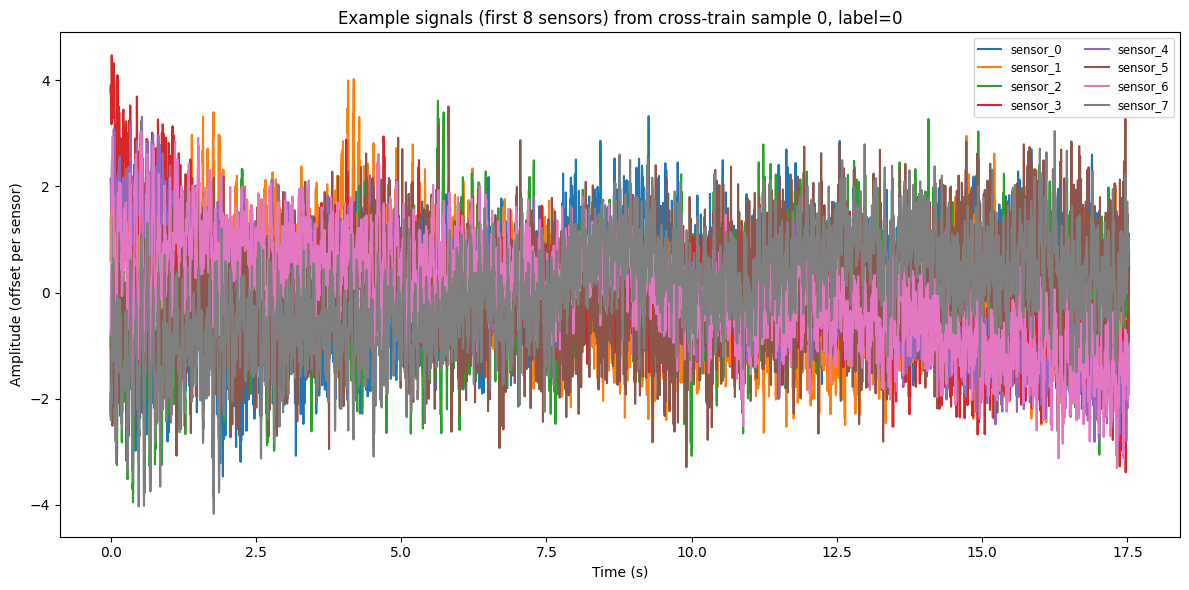

In [9]:
# Plot example time series from one sample (first sample)
X = data['X_cross_train']
y = np.load(os.path.join(DATA_DIR, 'y_cross_train.npy'))

sample_idx = 0
sample = X[sample_idx]  # shape: (n_sensors, n_times)
label = y[sample_idx]
n_sensors, n_times = sample.shape
print('sample index', sample_idx, 'label', label, 'sensors', n_sensors, 'timepoints', n_times)

time = np.arange(n_times) / fs
plt.figure(figsize=(12, 6))
sensors_to_plot = min(8, n_sensors)
for i in range(sensors_to_plot):
    plt.plot(time, sample[i], label=f'sensor_{i}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (offset per sensor)')
plt.title(f'Example signals (first {sensors_to_plot} sensors) from cross-train sample {sample_idx}, label={label}')
plt.legend(ncol=2, fontsize='small')
plt.tight_layout()
plt.show()

**Time-series plot — What it shows:** This plot displays raw (preprocessed) waveforms from multiple sensors over time. Each trace is offset for clarity. You can inspect for transient events, baseline shifts, large artifacts (spikes), and sensor-to-sensor differences.
**What to do with it:** Use this to visually verify signal quality, identify noisy channels or movement/artifact contamination, and select channels or time windows for analysis. Apply channel rejection, filtering, or ICA if you spot artifacts. For modelling, consider windowing or summary features (band power, envelope).

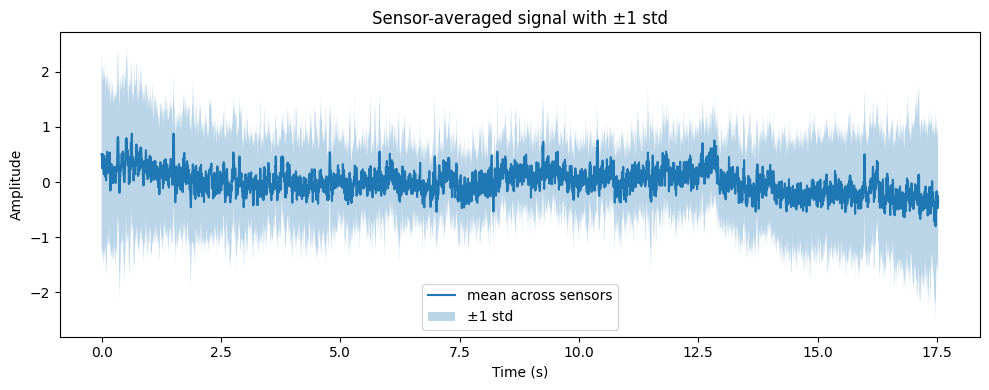

In [10]:
# Mean and std across sensors (sensor-averaged signal)
mean_signal = np.mean(sample, axis=0)
std_signal = np.std(sample, axis=0)

plt.figure(figsize=(10, 4))
plt.plot(time, mean_signal, label='mean across sensors')
plt.fill_between(time, mean_signal - std_signal, mean_signal + std_signal, alpha=0.3, label='±1 std')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Sensor-averaged signal with ±1 std')
plt.legend()
plt.tight_layout()
plt.show()

**Sensor-averaged signal (mean ± std) — What it shows:** The mean across sensors highlights common, large-scale patterns over time; the shaded area shows variability across sensors. Peaks that appear in the mean indicate events present across multiple channels.
**What to do with it:** Use the averaged signal to detect global events (e.g., task responses) and the std to find channels that deviate. If the mean dominates, consider using sensor-averaged features; if sensor variance is high, channel-specific features or spatial filtering (CSP/PCA) may help.

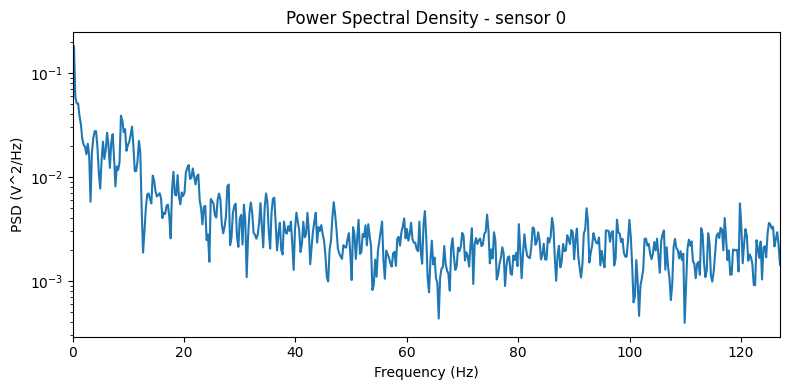

In [11]:
# Power Spectral Density (Welch) for one sensor
sensor_idx = 0
f, Pxx = signal.welch(sample[sensor_idx], fs=fs, nperseg=1024) if n_times >= 1024 else signal.welch(sample[sensor_idx], fs=fs)
plt.figure(figsize=(8, 4))
plt.semilogy(f, Pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('PSD (V^2/Hz)')
plt.title(f'Power Spectral Density - sensor {sensor_idx}')
plt.xlim(0, fs/2)
plt.tight_layout()
plt.show()

**Power Spectral Density (PSD) — What it shows:** The PSD shows how signal power is distributed across frequencies for a chosen sensor. Peaks indicate dominant rhythms (e.g., alpha ~8–12 Hz, beta ~13–30 Hz).
**What to do with it:** Use PSDs to choose filter bands, extract band-power features, detect abnormal spectral peaks, or compare condition differences. For models, consider band-power features, log-power, or using frequency-domain inputs.

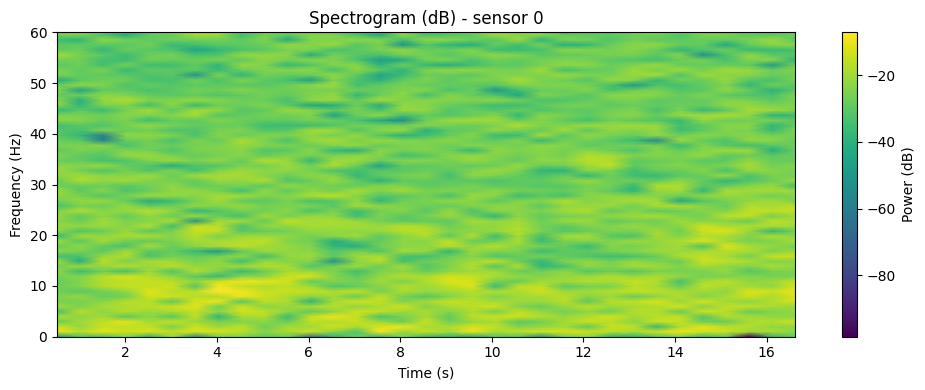

In [12]:
# Spectrogram for one sensor
sensor_idx = 0
f, t_spec, Sxx = signal.spectrogram(sample[sensor_idx], fs=fs, nperseg=256, noverlap=128)
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_spec, f, 10 * np.log10(Sxx + 1e-20), shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title(f'Spectrogram (dB) - sensor {sensor_idx}')
plt.ylim(0, 60)
plt.colorbar(label='Power (dB)')
plt.tight_layout()
plt.show()

**Spectrogram — What it shows:** Time-frequency representation of signal power for a sensor. It reveals when certain frequency bands increase or decrease over time (e.g., transient bursts, event-related changes).
**What to do with it:** Use spectrograms to spot transient oscillatory events and to design time-frequency features (e.g., sliding-window band power). They are helpful for event detection, aligning epochs to task onsets, or designing temporal filters.

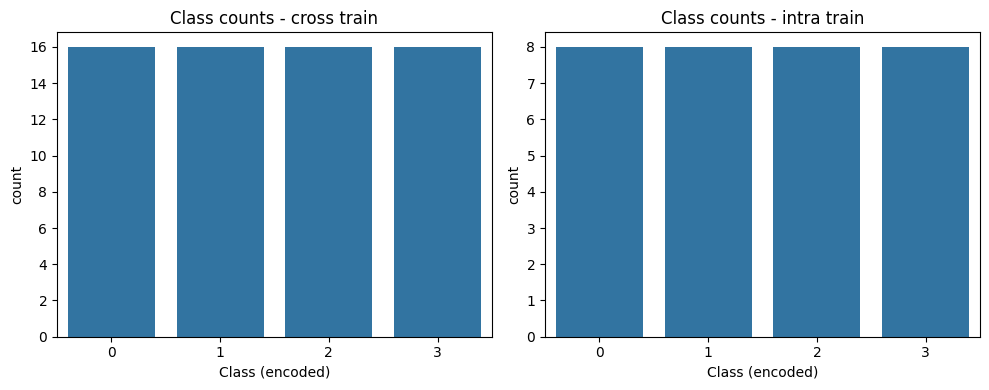

In [13]:
# Class distribution plots
# Load class arrays if present
y_cross = np.load(os.path.join(DATA_DIR, 'y_cross_train.npy'))
try:
    y_intra = np.load(os.path.join(DATA_DIR, 'y_intra_train.npy'))
except Exception:
    y_intra = None

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y_cross)
plt.title('Class counts - cross train')
plt.xlabel('Class (encoded)')

plt.subplot(1, 2, 2)
if y_intra is not None:
    sns.countplot(x=y_intra)
    plt.title('Class counts - intra train')
    plt.xlabel('Class (encoded)')
else:
    plt.text(0.5, 0.5, 'y_intra_train not found', ha='center')

plt.tight_layout()
plt.show()

**Class distributions — What it shows:** Bar plots of label counts for cross-subject and intra-subject training sets. They reveal class balance or imbalance.
**What to do with it:** If classes are imbalanced, use class weighting, resampling, or stratified splits when training models. Inspect whether particular classes are underrepresented and consider data augmentation or collecting more samples.



# PCA Analysis: Class Overlap Visualization

This section uses Principal Component Analysis (PCA) to visualize how overlapping the 4 task classes are in the feature space. Overlapping classes indicate weak signals that may require more advanced models or feature engineering. We'll examine both 2D and 3D projections.

Data shape after flattening: (64, 1104344)
Class distribution: [16 16 16 16]

PCA 2D - Explained variance ratio: [0.07612876 0.0534283 ]
PCA 2D - Total variance explained: 12.96%

PCA 3D - Explained variance ratio: [0.07612876 0.0534283  0.04124916]
PCA 3D - Total variance explained: 17.08%


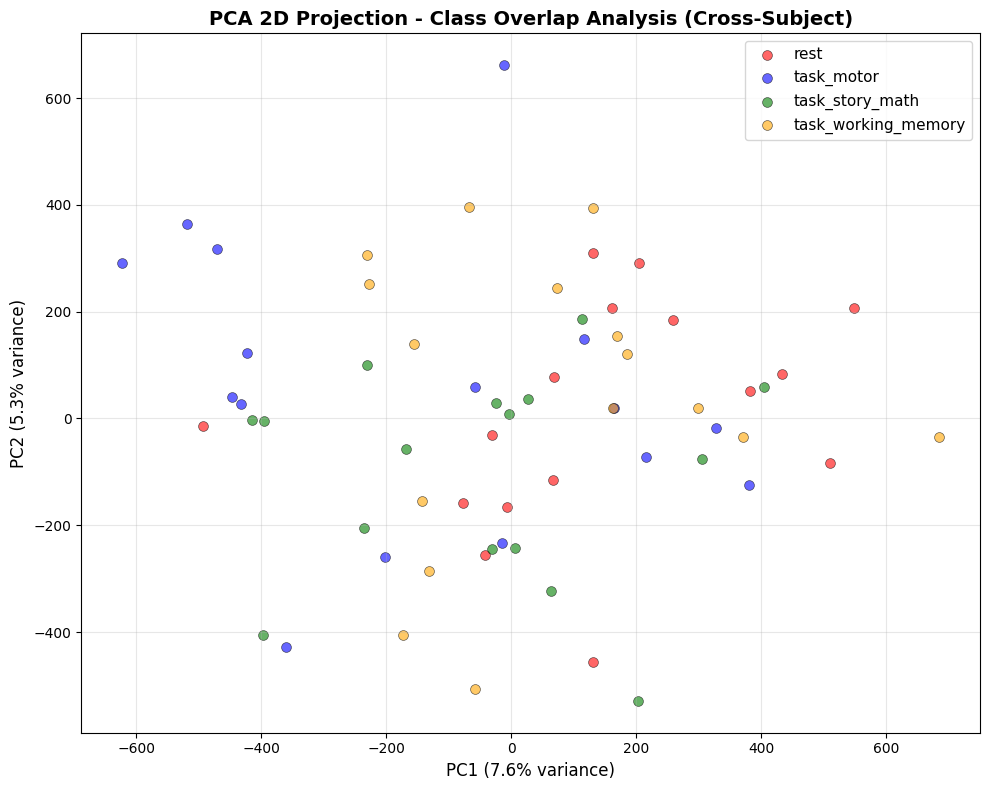

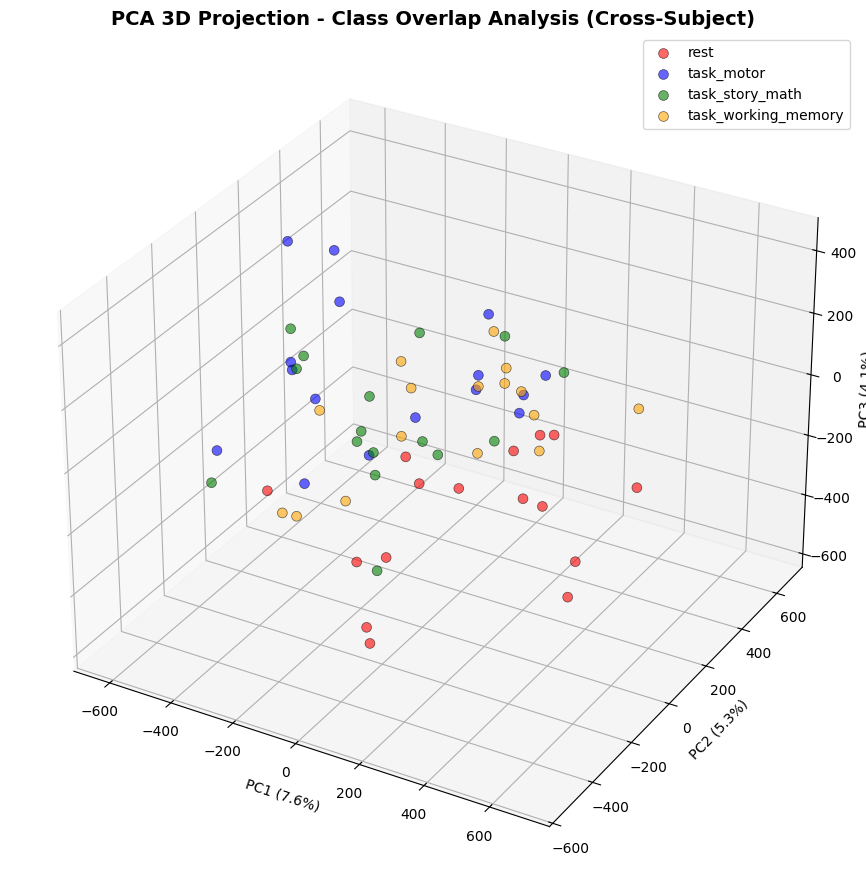


CLASS SEPARATION ANALYSIS

Inter-class distances (2D PCA):
────────────────────────────────────────
rest                 <-> task_motor          : 291.827
rest                 <-> task_story_math     : 219.996
rest                 <-> task_working_memory : 90.359
task_motor           <-> task_story_math     : 189.455
task_motor           <-> task_working_memory : 203.557
task_story_math      <-> task_working_memory : 177.230

Within-class spread (Intra-class std in 2D PCA space):
────────────────────────────────────────
rest                : 227.525
task_motor          : 288.172
task_story_math     : 215.204
task_working_memory : 253.348

INTERPRETATION GUIDE:
• High inter-class distance + Low intra-class spread = GOOD separation
• Low inter-class distance + High intra-class spread = POOR separation
• Poor separation suggests:
  - Classes have weak/overlapping signals
  - May need advanced models (CNN, attention mechanisms)
  - Consider feature engineering or more complex architecture

In [14]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Load preprocessed cross-subject training data
DATA_DIR = 'Preprocessed data'
X_cross_train = np.load(os.path.join(DATA_DIR, 'X_cross_train.npy'))
y_cross_train = np.load(os.path.join(DATA_DIR, 'y_cross_train.npy'))

# Class labels for interpretation
class_labels = np.array(CLASSES)

# Flatten the 3D data (samples, sensors, time) to 2D (samples, features)
# Shape: (n_samples, n_sensors, n_times) -> (n_samples, n_sensors * n_times)
n_samples, n_sensors, n_times = X_cross_train.shape
X_flat = X_cross_train.reshape(n_samples, -1)

print(f"Data shape after flattening: {X_flat.shape}")
print(f"Class distribution: {np.bincount(y_cross_train)}")

# Apply PCA with 2 components for 2D visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_flat)

print(f"\nPCA 2D - Explained variance ratio: {pca_2d.explained_variance_ratio_}")
print(f"PCA 2D - Total variance explained: {pca_2d.explained_variance_ratio_.sum():.2%}")

# Apply PCA with 3 components for 3D visualization
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_flat)

print(f"\nPCA 3D - Explained variance ratio: {pca_3d.explained_variance_ratio_}")
print(f"PCA 3D - Total variance explained: {pca_3d.explained_variance_ratio_.sum():.2%}")

# Define colors for each class
colors = ['red', 'blue', 'green', 'orange']
color_map = {i: colors[i] for i in range(len(CLASSES))}

# 2D PCA Visualization
fig, ax = plt.subplots(figsize=(10, 8))
for class_idx in range(len(CLASSES)):
    mask = y_cross_train == class_idx
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
               c=colors[class_idx], label=CLASSES[class_idx], 
               alpha=0.6, s=50, edgecolors='k', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('PCA 2D Projection - Class Overlap Analysis (Cross-Subject)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3D PCA Visualization
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for class_idx in range(len(CLASSES)):
    mask = y_cross_train == class_idx
    ax.scatter(X_pca_3d[mask, 0], X_pca_3d[mask, 1], X_pca_3d[mask, 2],
               c=colors[class_idx], label=CLASSES[class_idx], 
               alpha=0.6, s=50, edgecolors='k', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})', fontsize=10)
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})', fontsize=10)
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})', fontsize=10)
ax.set_title('PCA 3D Projection - Class Overlap Analysis (Cross-Subject)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

# Calculate and display class separation metrics
print("\n" + "="*60)
print("CLASS SEPARATION ANALYSIS")
print("="*60)

# Calculate mean distances between class centroids (2D)
centroids_2d = {}
for class_idx in range(len(CLASSES)):
    mask = y_cross_train == class_idx
    centroids_2d[class_idx] = np.mean(X_pca_2d[mask], axis=0)

print("\nInter-class distances (2D PCA):")
print("─" * 40)
for i in range(len(CLASSES)):
    for j in range(i+1, len(CLASSES)):
        dist = np.linalg.norm(centroids_2d[i] - centroids_2d[j])
        print(f"{CLASSES[i]:20} <-> {CLASSES[j]:20}: {dist:.3f}")

# Intra-class spread (within-class variance)
print("\nWithin-class spread (Intra-class std in 2D PCA space):")
print("─" * 40)
for class_idx in range(len(CLASSES)):
    mask = y_cross_train == class_idx
    std_dev = np.std(X_pca_2d[mask], axis=0)
    spread = np.mean(std_dev)
    print(f"{CLASSES[class_idx]:20}: {spread:.3f}")

print("\n" + "="*60)
print("INTERPRETATION GUIDE:")
print("="*60)
print("• High inter-class distance + Low intra-class spread = GOOD separation")
print("• Low inter-class distance + High intra-class spread = POOR separation")
print("• Poor separation suggests:")
print("  - Classes have weak/overlapping signals")
print("  - May need advanced models (CNN, attention mechanisms)")
print("  - Consider feature engineering or more complex architectures")
print("="*60)